# Strategy 2: Cluster First, PCA for Visualization Only
**Dataset:** Customer Personality Analysis
**Download:** https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis
**File name:** `marketing_campaign.csv`

**Why cluster first here:**
This dataset has ~28 features measuring largely independent customer dimensions —
demographics, spending by product category, purchasing channels, campaign responses.
Because features are relatively independent, PCA cannot compress them well —
the first 2 PCs only capture ~40-50% variance, meaning PCA first would throw away
more than half the information before clustering even starts.
We cluster on all features, then use PCA only to produce a drawable 2D picture.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

## 1. Load and explore the data

In [2]:
df = pd.read_csv("marketing_campaign.csv", sep='\t')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [3]:
df.shape

(2240, 29)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

## 2. Clean and engineer features

In [5]:
# Drop non-numeric or irrelevant columns
df.drop(['ID', 'Dt_Customer', 'Z_CostContact', 'Z_Revenue'], axis=1, inplace=True, errors='ignore')

# Check missing values
print(df.isnull().sum())

Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Response                0
dtype: int64


In [6]:
# Fill missing numeric values with median
df.fillna(df.median(numeric_only=True), inplace=True)

# Encode Education and Marital_Status if present
if 'Education' in df.columns:
    df['Education'] = df['Education'].map({
        'Basic': 0, '2n Cycle': 1, 'Graduation': 2, 'Master': 3, 'PhD': 4
    }).fillna(2)

if 'Marital_Status' in df.columns:
    df['Marital_Status'] = df['Marital_Status'].map({
        'Single': 0, 'Together': 1, 'Married': 1,
        'Divorced': 0, 'Widow': 0, 'Alone': 0, 'YOLO': 0, 'Absurd': 0
    }).fillna(0)

# Keep only numeric columns
df_numeric = df.select_dtypes(include=[np.number])
print(f"\nFeatures used for clustering: {df_numeric.shape[1]}")
print(df_numeric.columns.tolist())


Features used for clustering: 25
['Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Response']


## 3. Scale features

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_numeric)
print("Shape:", X_scaled.shape)

Shape: (2240, 25)


## 4. Check variance distribution — this is why we cluster first

Run PCA diagnostically to see how variance is distributed.
If 2 PCs only retain ~40-50%, clustering in PCA space would lose too much information.
This confirms we should cluster on full features and use PCA only for visualization.


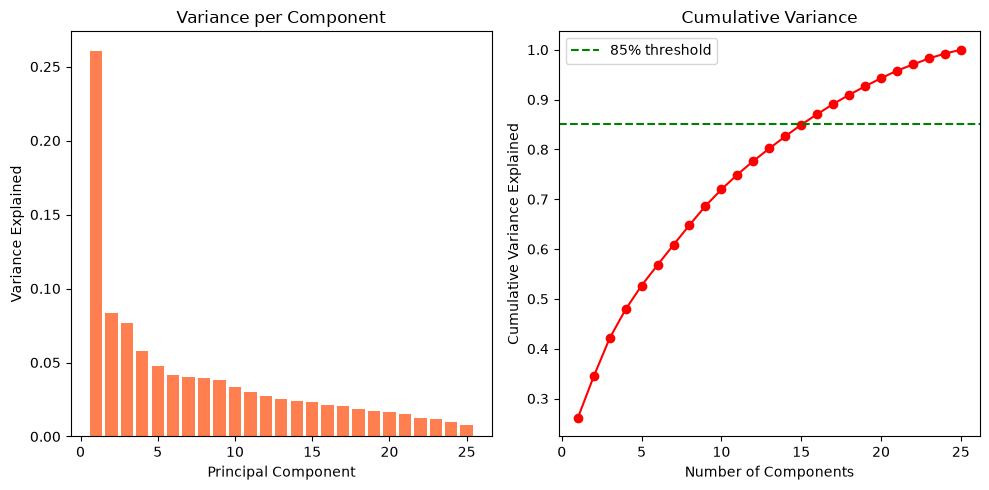

In [8]:
pca_check = PCA()
pca_check.fit(X_scaled)

cumulative_variance = np.cumsum(pca_check.explained_variance_ratio_)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.bar(range(1, len(pca_check.explained_variance_ratio_) + 1),
        pca_check.explained_variance_ratio_, color='coral')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.title('Variance per Component')

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', color='red')
plt.axhline(y=0.85, color='g', linestyle='--', label='85% threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance Explained')
plt.title('Cumulative Variance')
plt.legend()

plt.tight_layout()
plt.show()

In [9]:
# Print 2 PC variance — this confirms clustering first is the right call
two_pc_variance = cumulative_variance[1]
print(f"Variance retained by just 2 PCs: {two_pc_variance*100:.1f}%")
print()
if two_pc_variance < 0.60:
    print("Only 2 PCs retain less than 60% variance.")
    print("Clustering in PCA space would discard too much information.")
    print("Decision confirmed: cluster on full features, use PCA only for visualization.")
else:
    print("Check how many components reach 85% threshold:")
    for i, v in enumerate(cumulative_variance, 1):
        print(f"  {i} components: {v*100:.1f}%")
        if v >= 0.85:
            break

Variance retained by just 2 PCs: 34.4%

Only 2 PCs retain less than 60% variance.
Clustering in PCA space would discard too much information.
Decision confirmed: cluster on full features, use PCA only for visualization.


## 5. Find optimal K on the full feature space

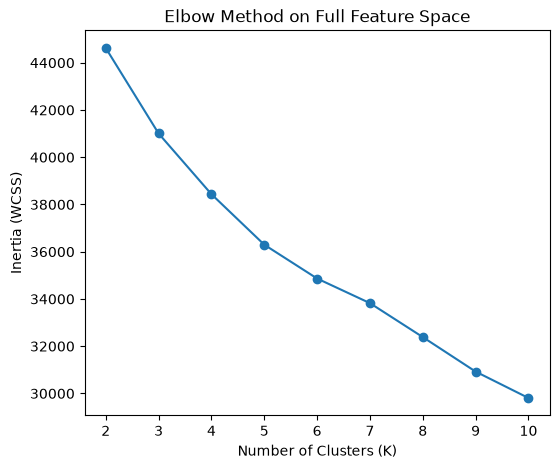

In [10]:
# Elbow Method
inertias = []
range_k = list(range(2, 11))

for k in range_k:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(6, 5))
plt.plot(range_k, inertias, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method on Full Feature Space')
plt.xticks(range_k)
plt.show()

K=2: silhouette score = 0.241
K=3: silhouette score = 0.165
K=4: silhouette score = 0.165
K=5: silhouette score = 0.173
K=6: silhouette score = 0.102
K=7: silhouette score = 0.109
K=8: silhouette score = 0.108
K=9: silhouette score = 0.112
K=10: silhouette score = 0.112


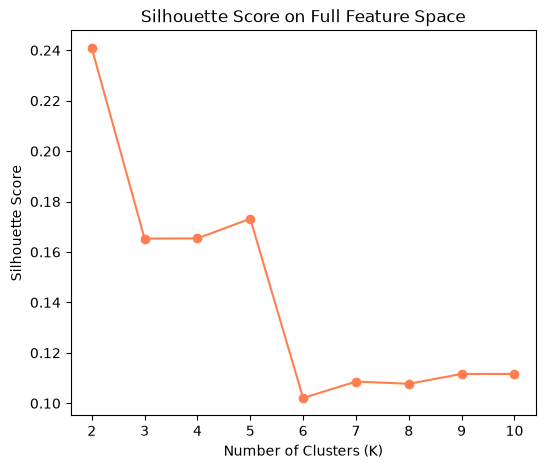


Best K by silhouette: 2


In [11]:
# Silhouette Score on full features
sil_scores = []
for k in range_k:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)
    print(f"K={k}: silhouette score = {score:.3f}")

plt.figure(figsize=(6, 5))
plt.plot(range_k, sil_scores, marker='o', color='coral')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score on Full Feature Space')
plt.xticks(range_k)
plt.show()

best_k = range_k[np.argmax(sil_scores)]
print(f"\nBest K by silhouette: {best_k}")

## 6. Final clustering on full feature space

In [12]:
kmeans_final = KMeans(n_clusters=best_k, n_init=10, random_state=42)
df_numeric['Cluster'] = kmeans_final.fit_predict(X_scaled)

print("Cluster sizes:")
print(df_numeric['Cluster'].value_counts().sort_index())
print(f"\nFinal silhouette score (full feature space): {silhouette_score(X_scaled, df_numeric['Cluster']):.3f}")

Cluster sizes:
Cluster
0     881
1    1359
Name: count, dtype: int64

Final silhouette score (full feature space): 0.241


## 7. PCA for visualization ONLY

We now apply PCA purely to produce a 2D plot.
The clustering result above is unchanged — PCA is not involved in the clustering decision.
Note that the plot is an approximation: only ~40-50% of original variance is shown.
We always print the retained variance as a disclaimer on the title.


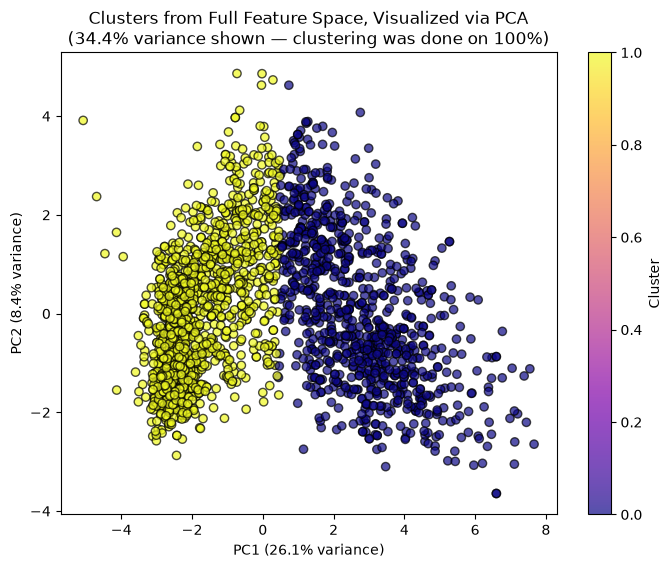

Note: This plot shows 34.4% of original variance.
Clustering was performed on the full feature space — PCA was only used for this plot.


In [13]:
pca_viz = PCA(n_components=2)
X_pca_viz = pca_viz.fit_transform(X_scaled)
variance_shown = sum(pca_viz.explained_variance_ratio_) * 100

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca_viz[:, 0], X_pca_viz[:, 1],
                      c=df_numeric['Cluster'], cmap='plasma', edgecolors='k', alpha=0.7)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 ({pca_viz.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca_viz.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title(f'Clusters from Full Feature Space, Visualized via PCA\n({variance_shown:.1f}% variance shown — clustering was done on 100%)')
plt.show()

print(f"Note: This plot shows {variance_shown:.1f}% of original variance.")
print("Clustering was performed on the full feature space — PCA was only used for this plot.")

## 8. Interpret clusters using cluster mean heatmap

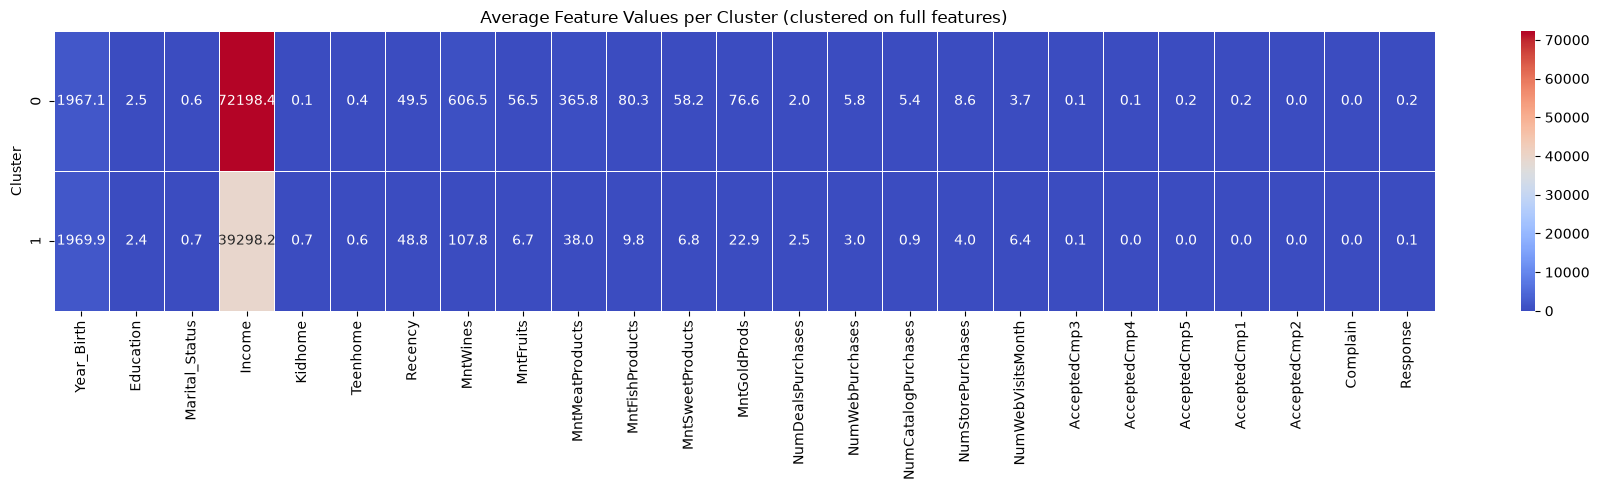

In [14]:
cluster_means = df_numeric.groupby('Cluster').mean()

plt.figure(figsize=(18, 5))
sns.heatmap(cluster_means, annot=True, fmt='.1f', cmap='coolwarm', linewidths=0.5)
plt.title('Average Feature Values per Cluster (clustered on full features)')
plt.tight_layout()
plt.show()

## 9. Parallel coordinates plot — see all features per cluster at once

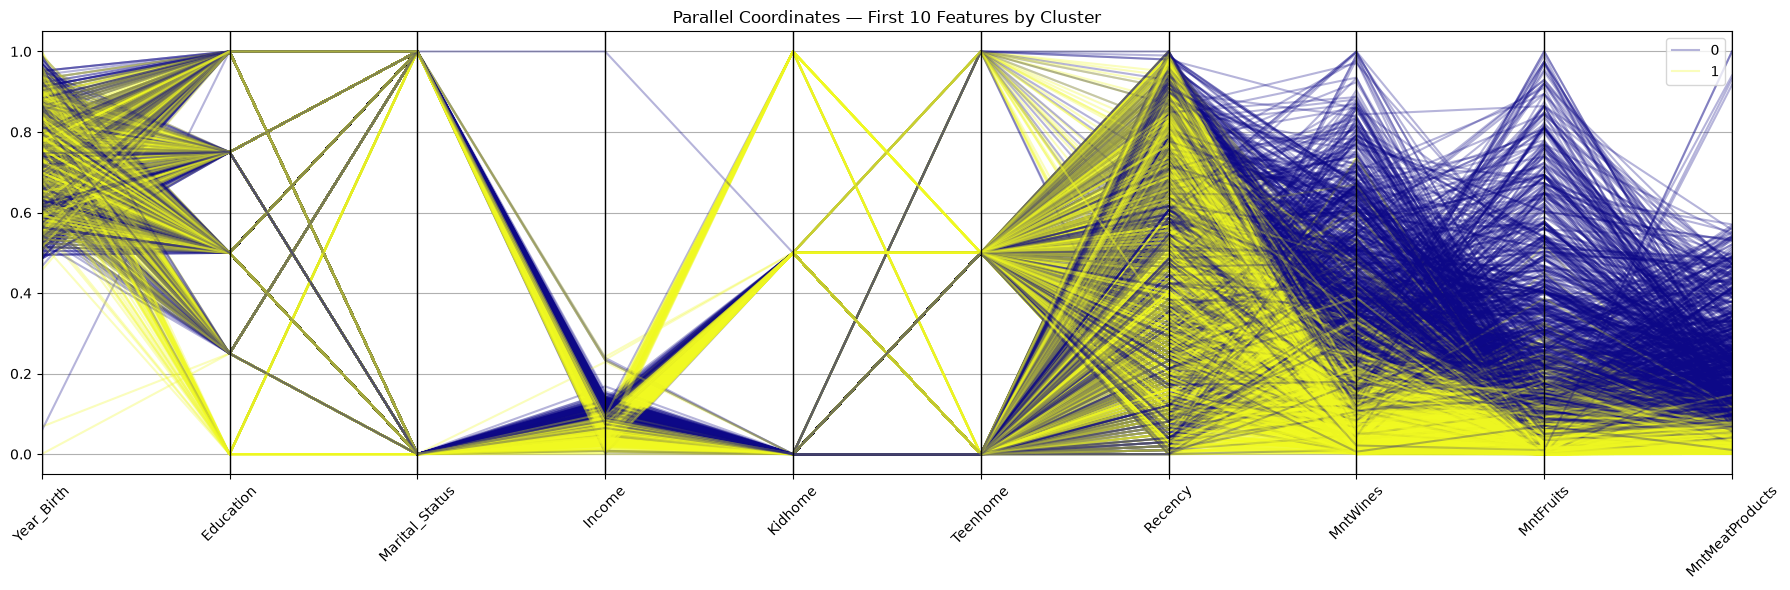

In [15]:
from pandas.plotting import parallel_coordinates

df_plot = df_numeric.copy()
df_plot['Cluster_label'] = df_plot['Cluster'].astype(str)

# Normalize features to 0-1 for readable parallel coordinates
cols = [c for c in df_plot.columns if c not in ['Cluster', 'Cluster_label']]
df_norm = df_plot.copy()
for col in cols:
    min_val = df_norm[col].min()
    max_val = df_norm[col].max()
    if max_val > min_val:
        df_norm[col] = (df_norm[col] - min_val) / (max_val - min_val)

plt.figure(figsize=(18, 6))
parallel_coordinates(df_norm[cols[:10] + ['Cluster_label']], 'Cluster_label',
                     colormap='plasma', alpha=0.3)
plt.title('Parallel Coordinates — First 10 Features by Cluster')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 10. Summary — why this strategy was correct for this dataset

In [16]:
pca_2pc_variance = cumulative_variance[1] * 100
print("=" * 55)
print("Strategy Validation Summary")
print("=" * 55)
print(f"Total features used for clustering : {X_scaled.shape[1]}")
print(f"Variance retained by 2 PCs         : {pca_2pc_variance:.1f}%")
print(f"Variance retained by visualization : {variance_shown:.1f}%")
print()
print("Because 2 PCs only captured ~40-50% of variance,")
print("PCA first would have discarded ~50%+ of information")
print("before clustering even started.")
print()
print("Correct approach: cluster on full features,")
print("use PCA only for visualization afterward.")
print()
print(f"Best K                             : {best_k}")
print(f"Final silhouette score             : {silhouette_score(X_scaled, df_numeric['Cluster']):.3f}")

Strategy Validation Summary
Total features used for clustering : 25
Variance retained by 2 PCs         : 34.4%
Variance retained by visualization : 34.4%

Because 2 PCs only captured ~40-50% of variance,
PCA first would have discarded ~50%+ of information
before clustering even started.

Correct approach: cluster on full features,
use PCA only for visualization afterward.

Best K                             : 2
Final silhouette score             : 0.241
